17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training RNN Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.5753 - loss: 0.6657 - val_accuracy: 0.7150 - val_loss: 0.5454
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8240 - loss: 0.4066 - val_accuracy: 0.8068 - val_loss: 0.4279
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9124 - loss: 0.2315 - val_accuracy: 0.8138 - val_loss: 0.4351

Training LSTM Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 112ms/step - accuracy: 0.6785 - loss: 0.5708 - val_accuracy: 0.8342 - val_loss: 0.3886
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8939 - loss: 0.2690 - val_accuracy: 0.8702 - val_loss: 0.3172
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.9308 - loss: 0.1928 - val_accuracy: 0.8790 - val_loss: 0.3115

Training GRU Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 151ms/step - accuracy: 0.6590 - loss: 0.5864 - val_accuracy: 0.8392 - val_loss: 0.3797
Epoch 2/3
313/313 ━━━━━

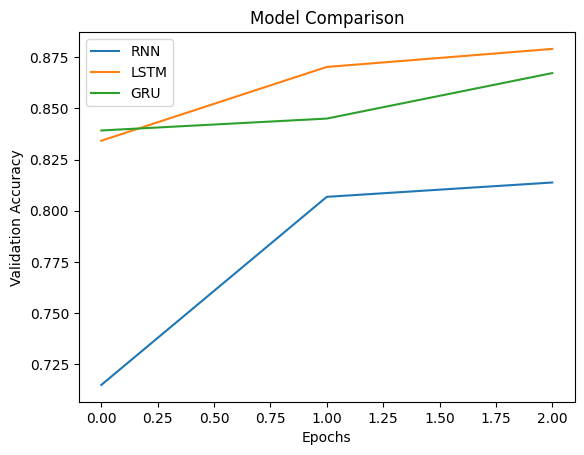


Test Accuracy
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8145 - loss: 0.4389
RNN: 0.8133999705314636
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8651 - loss: 0.3315
LSTM: 0.8669999837875366
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8607 - loss: 0.3324
GRU: 0.8606799840927124


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load IMDb Dataset
# -------------------------------
vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# -------------------------------
# 2. RNN Model
# -------------------------------
rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining RNN Model...")
rnn_history = rnn_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)

# -------------------------------
# 3. LSTM Model
# -------------------------------
lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(x_train, y_train,
                              epochs=3,
                              batch_size=64,
                              validation_split=0.2)

# -------------------------------
# 4. GRU Model
# -------------------------------
gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining GRU Model...")
gru_history = gru_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)

# -------------------------------
# 5. Compare Learning Curves
# -------------------------------
plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# -------------------------------
# 6. Test Accuracy
# -------------------------------
print("\nTest Accuracy")

print("RNN:", rnn_model.evaluate(x_test, y_test)[1])
print("LSTM:", lstm_model.evaluate(x_test, y_test)[1])
print("GRU:", gru_model.evaluate(x_test, y_test)[1])